In [46]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# **Frequent Value Imputation**

In [47]:
df = pd.read_csv("train.csv",usecols=['GarageQual','FireplaceQu','SalePrice'])
df.sample(4)

,FireplaceQu,GarageQual,SalePrice
349,Ex,TA,437154
155,NaN,NaN,79000
45,Gd,TA,319900
248,NaN,TA,180000


In [48]:
print(df.shape)
print(df.isnull().mean()*100)

(1460, 3)
FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64


In [49]:
df.isnull().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


Text(0, 0.5, 'Number of house')

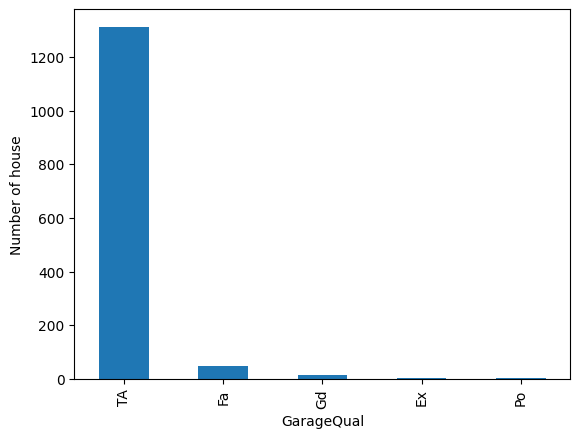

In [50]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel("Number of house")

Text(0.5, 1.0, 'GarageQual')

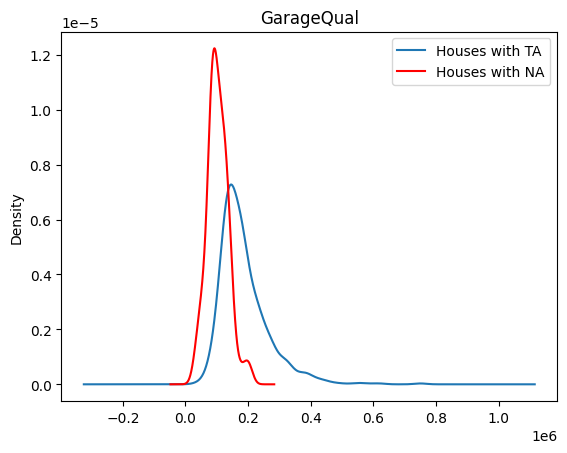

In [51]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color = 'red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA','Houses with NA']
ax.legend(lines,labels,loc='best')

plt.title("GarageQual")

In [52]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [53]:
df['GarageQual'].fillna('TA',inplace=True)

/tmp/ipykernel_1338/584385255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA',inplace=True)


<Axes: xlabel='GarageQual'>

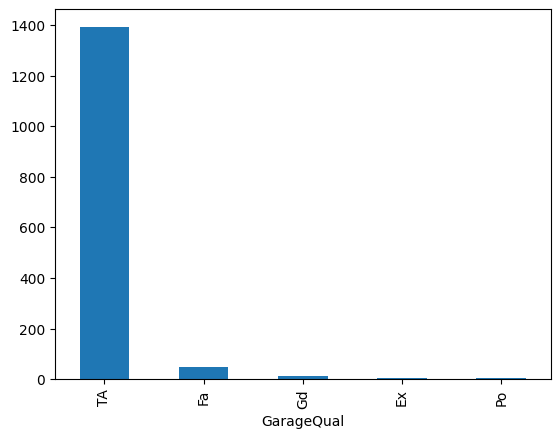

In [54]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'After Fillna GarageQual')

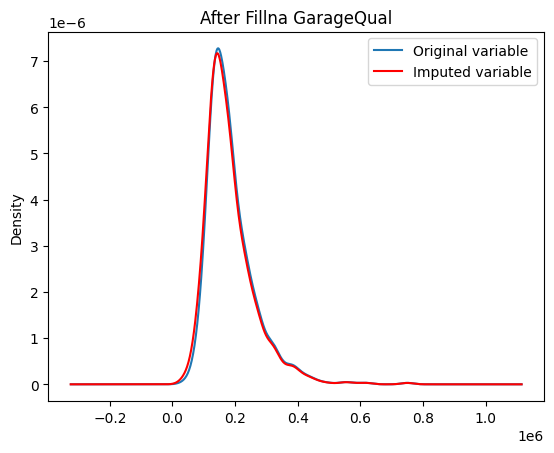

In [55]:
fig = plt.figure()
ax= fig.add_subplot(111)

temp.plot(kind = 'kde',ax=ax)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Original variable','Imputed variable']
ax.legend(lines,labels,loc='best')
plt.title('After Fillna GarageQual')

<Axes: xlabel='FireplaceQu'>

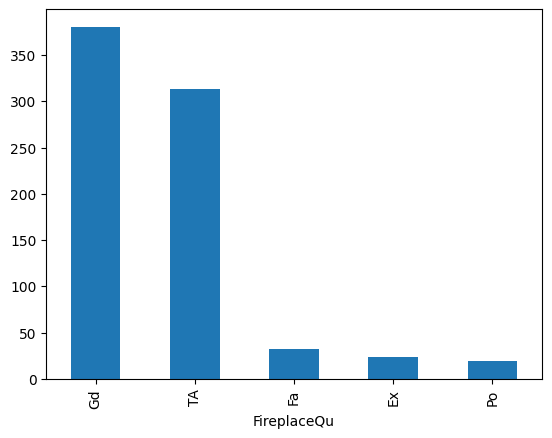

In [56]:
df['FireplaceQu'].value_counts().plot(kind='bar')

if we are replacing with the most frequent value so one category must have to be the highly dominant so in this case 2 categories are most frequent So this is not applicable for it. here we see how ->

Text(0.5, 1.0, 'FireplaceQu')

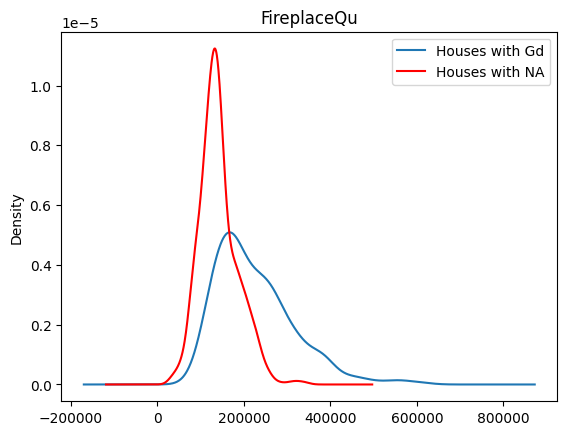

In [57]:
fig = plt.figure()
ax = fig.add_subplot(111)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels = ax.get_legend_handles_labels()
labels =['Houses with Gd','Houses with NA']
ax.legend(lines,labels,loc='best')
plt.title('FireplaceQu')

/tmp/ipykernel_1338/2468842503.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd',inplace=True)


<Axes: xlabel='FireplaceQu'>

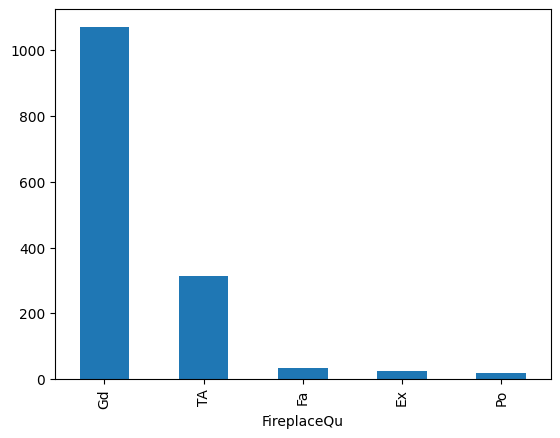

In [58]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']
df['FireplaceQu'].fillna('Gd',inplace=True)
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'After FireplaceQu')

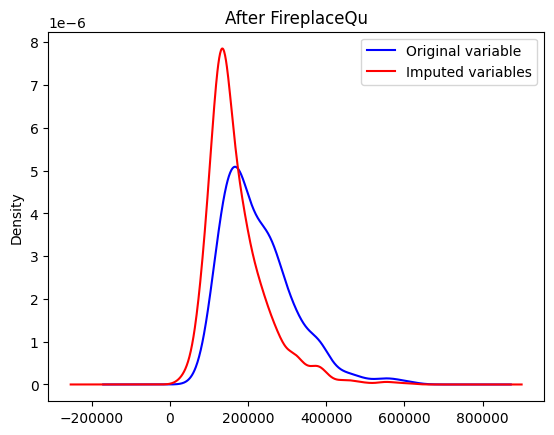

In [59]:
fig=plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax,color='blue')
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels = ax.get_legend_handles_labels()
labels=['Original variable','Imputed variables']
ax.legend(lines,labels,loc='best')
plt.title('After FireplaceQu')


Here , we can see the distribution is not similar and we cannot map both the features.

In [60]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy ='most_frequent')
X_train =imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [62]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

# **Missing Category Imputation**

In [64]:
dp = pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [65]:
dp.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

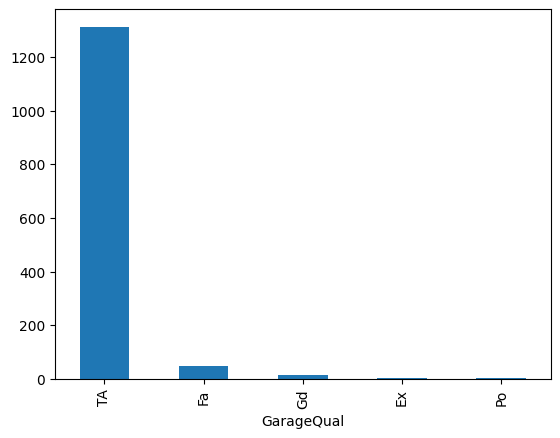

In [67]:
dp['GarageQual'].value_counts().plot(kind='bar')

In [70]:
dp['GarageQual'].fillna('missing',inplace=True)

/tmp/ipykernel_1338/3144933277.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dp['GarageQual'].fillna('missing',inplace=True)


<Axes: xlabel='GarageQual'>

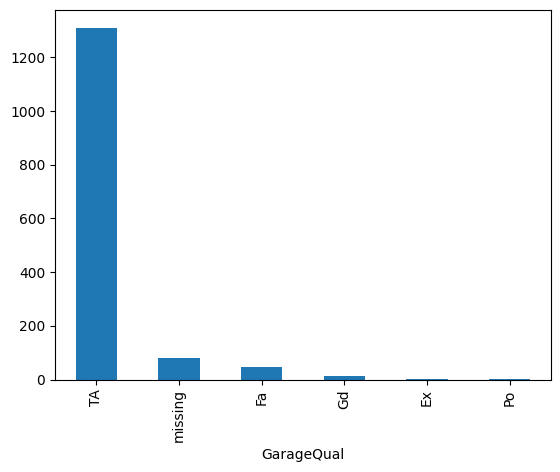

In [71]:
dp['GarageQual'].value_counts().plot.bar()

In [72]:
from sklearn.model_selection import train_test_split
x=dp.drop(columns=['SalePrice'])
Y = dp['SalePrice']
X_train,X_test,y_train,y_test = train_test_split(x,Y,test_size=0.2,random_state=42)

In [74]:
imputer2 = SimpleImputer(strategy ='constant',fill_value='Missing')
X_train = imputer2.fit_transform(X_train)
X_test = imputer2.transform(X_test)

In [75]:
imputer2.statistics_

array(['Missing', 'Missing'], dtype=object)